# Прогнозирование стоимости недвижимости
**Цель:** Построение модели машинного обучения для предсказания стоимости объектов недвижимости на основе данных агрегатора Zingat.

# Этап 1. Исследование данных (EDA)

 **Задачи:**
1. Знакомство с данными (загрузка, структура, целевая переменная).
2. Описательная статистика числовых и категориальных признаков.
3. Визуальный анализ распределений и зависимостей.
4. Анализ пропусков, дубликатов и логических аномалий.
5. Формирование первичных гипотез.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, median_absolute_error, r2_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

RANDOM_STATE = 42

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# 1.1 Знакомство с данными

Загружаем датасет, изучаем его размерность, типы данных и выводим строки для понимания структуры. Источник данных - агрегатор недвижимости Zingat (Турция), цены в турецких лирах.

In [3]:
df = pd.read_csv('real_estate_data.csv', encoding='utf-8')
print(f"Размерность датасета: {df.shape}")

Размерность датасета: (403487, 17)


In [4]:
df.info()

Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402

## Первые 5 строк

In [5]:
display(df.head(5))

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


**Описание признаков**
* `id` — уникальный идентификатор объявления.
* `type` — тип недвижимости (в датасете только Konut = Жилая).
* `sub_type` — подтип недвижимости (например, Daire = Квартира, Rezidans = Резиденция).
* `start_date` — дата начала показа объявления на рынке.
* `end_date` — дата снятия объявления с публикации.
* `listing_type` — код типа объявления (число 1/2/3, расшифровку определим ниже по ценам).
* `tom` (Time on market) — время нахождения объекта на рынке (в днях).
* `building_age` — возраст здания. Либо точный возраст ('0', '3'), либо диапазон ('11-15 arası' = "от 11 до 15"), либо '40 ve üzeri' = "40 и больше".
* `total_floor_count` — этажность здания, тоже текстовая категория ('10-20 arası', '20 ve üzeri').
* `floor_no` — этаж объекта. Тоже текст: кроме чисел есть 'Zemin Kat' (первый/цокольный), 'Giriş Katı' (вход), 'Kot 1/2/3' (уровни ниже входа), 'Çatı Katı' (мансарда), 'Bodrum Kat' (подвал) и т.д.
* `room_count` — количество комнат (формат "2+1" означает 2 спальни и 1 гостиную).
* `size` — площадь объекта недвижимости (в квадратных метрах).
* `address` — адрес объекта (Город / Округ / Район).
* `furnished` — наличие мебели.
* `heating_type` — тип системы отопления.
* `price` — стоимость недвижимости. **Целевая переменная.**
* `price_currency` — валюта стоимости.

# 1.2 Описательная статистика
Рассчитываем базовые статистики для числовых и категориальных признаков.

## Числовые признаки

In [8]:
display(df.describe().round(2))

,id,listing_type,tom,size,furnished,price
count,403487.00,403487.00,403487.00,257481.00,0.0,4.027720e+05
mean,201744.00,1.29,57.02,279.35,NaN,3.546417e+05
std,116476.81,0.47,44.36,9429.20,NaN,4.809503e+06
min,1.00,1.00,0.00,1.00,NaN,-2.500000e+02
25%,100872.50,1.00,29.00,85.00,NaN,2.500000e+03
50%,201744.00,1.00,40.00,110.00,NaN,1.990000e+05
75%,302615.50,2.00,90.00,140.00,NaN,3.420000e+05
max,403487.00,3.00,180.00,948235.00,NaN,2.000000e+09


Тут сразу видно несколько проблем:
* минимальная цена отрицательная (-250), такого быть не может;
* максимальная площадь 948 235 кв.м, это явно мусор;
* среднее по цене (354 тыс.) сильно больше медианы (199 тыс.) - значит распределение сильно скошено вправо;
* 25-й перцентиль цены всего 2500 лир. Для квартиры на продажу это нереально, похоже на месячную аренду. Проверим это ниже;
* `furnished` вообще пустой (count = 0).

## Категориальные признаки

In [9]:
display(df.describe(include=['object']))

,type,sub_type,start_date,end_date,building_age,total_floor_count,floor_no,room_count,address,heating_type,price_currency
count,403487,403487,403487,266298,376097,375466,368191,403487,403487,375517,402772
unique,1,12,181,181,14,12,44,37,7842,16,4
top,Konut,Daire,10/11/18,12/19/18,0,4,2,3+1,Balıkesir/Edremit/Akçay,Kombi (Doğalgaz),TRY
freq,403487,354549,4064,3048,140174,83082,60914,157363,5611,204150,400677


Категория `type` содержит всего одно уникальное значение, толку от неё нет. Ещё заметно, что `address` имеет 7842 уникальных значения - напрямую такое в модель не засунешь, надо будет резать на части. И у `price_currency` 4 уникальных значения, хотя мы думали, что там только лиры.

## Проверяем, что такое `listing_type`

По описательной статистике мы заподозрили, что в датасете лежат вперемешку продажа и аренда. Посмотрим на медианную цену по каждому коду.

In [10]:
listing_stats = df.groupby('listing_type')['price'].agg(['count', 'median', 'mean']).round(0)
display(listing_stats)

SALE_TYPE = listing_stats['median'].idxmax()
print(f"Код продажи (самая высокая медианная цена): {SALE_TYPE}")

,count,median,mean
listing_type,,,
1,286420,269000.0,491938.0
2,114118,1200.0,16986.0
3,2234,70.0,123.0


Код продажи (самая высокая медианная цена): 1


Вот и подтверждение. У одного кода медиана в районе сотен тысяч лир (это продажа), у другого - пара тысяч (это месячная аренда). Это очень важная находка: в таргете лежат две совершенно разные величины. Именно поэтому у цены такая дикая асимметрия и поэтому корреляции ниже будут нулевые.

Модель, обученная на такой смеси, будет бесполезной: она не поймёт, предсказывать ей стоимость квартиры или арендную ставку. На этапе очистки оставим только объявления о продаже (код с самой высокой медианной ценой).

## Проверяем валюту

In [11]:
display(df['price_currency'].value_counts(dropna=False))

price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64

Основная масса в лирах (TRY), но есть несколько тысяч объявлений в других валютах. Их цены живут в совсем другом масштабе (доллар примерно в 5-6 раз дороже лиры на тот период), поэтому такие строки просто удалим, чтобы не портить таргет.

## Проверка асимметрии

Проверим насколько распределение данных отклоняется от нормального

In [12]:
price_skewness = df['price'].skew()
print(f"Асимметрия целевой переменной: {price_skewness:.2f}")
if price_skewness > 1 or price_skewness < -1:
    print("Высокая асимметрия!")

Асимметрия целевой переменной: 308.51
Высокая асимметрия!


Асимметрия огромная. Часть её объясняется смесью аренды и продажи, часть - выбросами. В любом случае целевую переменную придётся логарифмировать, чтобы модели было проще.

# 1.3 Визуальный анализ
Строим гистограммы распределения, диаграммы рассеяния, боксплоты и тепловую карту корреляций. Чтобы графики не сливались из-за экстремальных значений, временно отфильтруем аномалии и оставим только продажу.

## Гистограммы ключевых признаков

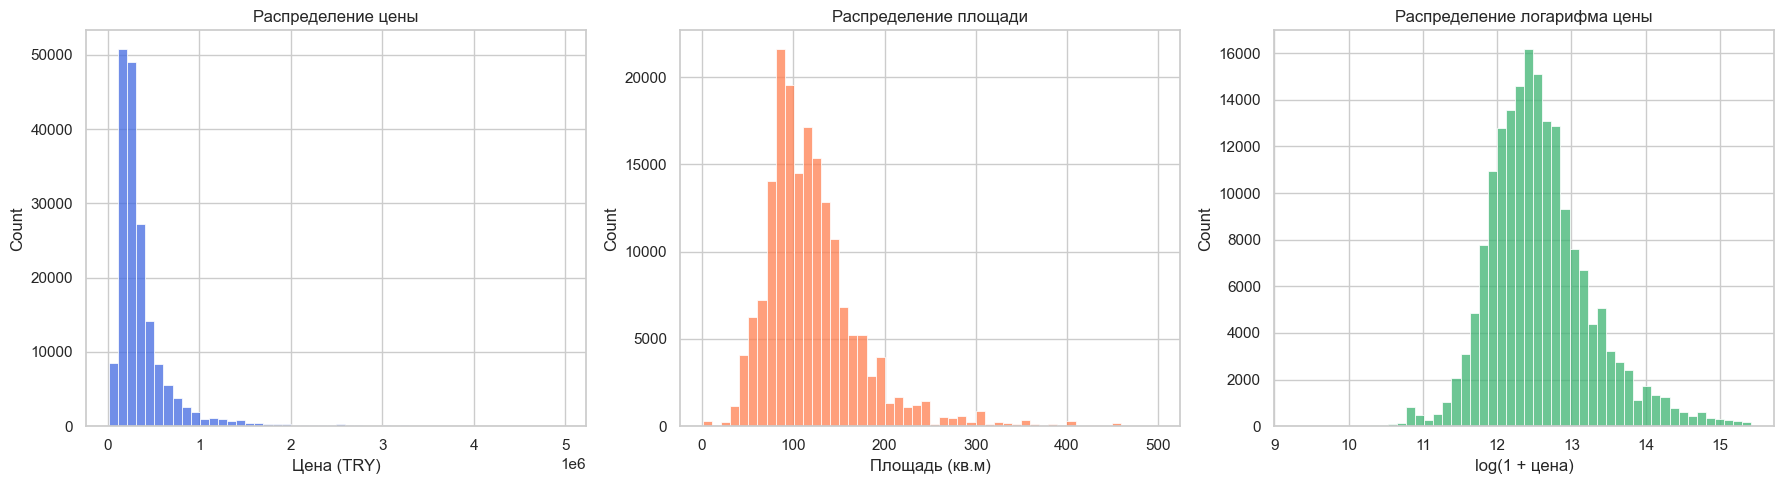

In [14]:
df_vis = df[(df['listing_type'] == SALE_TYPE) &
            (df['price_currency'] == 'TRY') &
            (df['price'] > 10000) & (df['price'] < 5000000) &
            (df['size'] < 500)].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_vis['price'], bins=50, ax=axes[0], color='royalblue')
axes[0].set_title('Распределение цены')
axes[0].set_xlabel('Цена (TRY)')

sns.histplot(df_vis['size'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Распределение площади')
axes[1].set_xlabel('Площадь (кв.м)')

sns.histplot(np.log1p(df_vis['price']), bins=50, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Распределение логарифма цены')
axes[2].set_xlabel('log(1 + цена)')

plt.tight_layout()
plt.show()

* `price`: даже после фильтрации хвост вправо остаётся длинным.
* `size`: распределение более-менее нормальное, с небольшим хвостом.
* `log(price)`: а вот тут форма становится почти колоколом. Это прямое подтверждение, что логарифмирование таргета - правильный ход.

## Диаграмма рассеяния "Площадь - Цена"

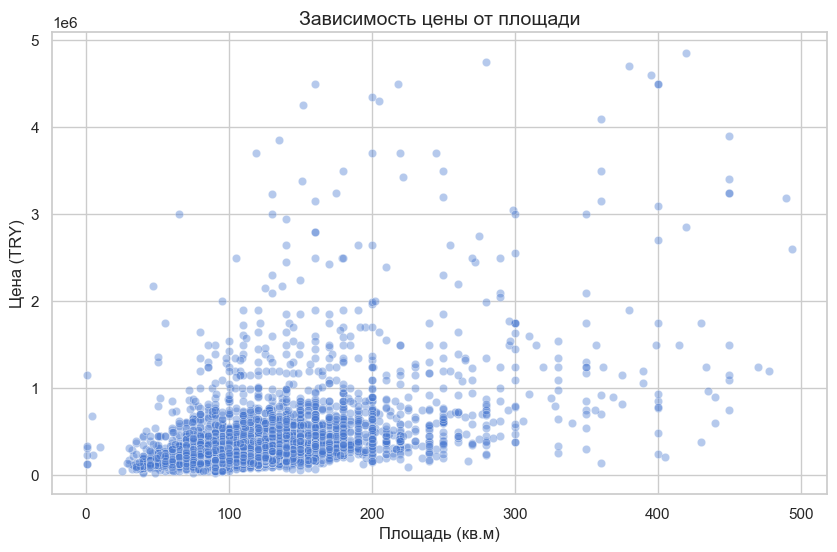

In [15]:
plt.figure(figsize=(10, 6))
scatter_sample = df_vis.sample(min(5000, len(df_vis)), random_state=RANDOM_STATE)
sns.scatterplot(x='size', y='price', data=scatter_sample, alpha=0.4, color='b')
plt.title('Зависимость цены от площади', fontsize=14)
plt.xlabel('Площадь (кв.м)')
plt.ylabel('Цена (TRY)')
plt.show()

Зависимость цены от площади ожидаемо прямая: чем больше метров, тем дороже. При этом у крупных объектов разброс цен заметно шире — на цену явно влияет что-то ещё, скорее всего район.

## Цена в зависимости от количества комнат

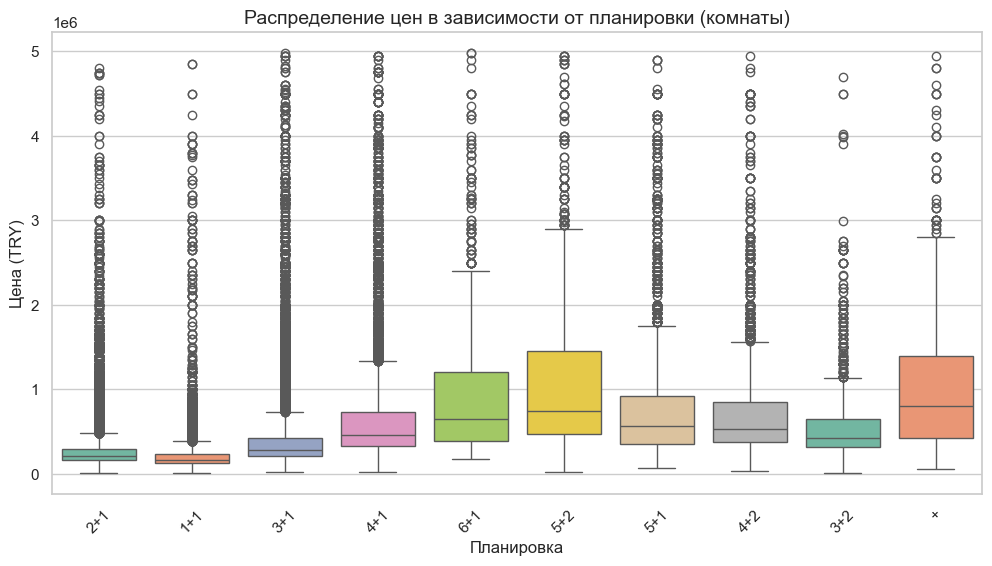

In [16]:
plt.figure(figsize=(12, 6))
top_rooms = df_vis['room_count'].value_counts().nlargest(10).index
plot_data = df_vis[df_vis['room_count'].isin(top_rooms)]

sns.boxplot(x='room_count', y='price', data=plot_data, hue='room_count', palette='Set2', legend=False)
plt.title('Распределение цен в зависимости от планировки (комнаты)', fontsize=14)
plt.xlabel('Планировка')
plt.ylabel('Цена (TRY)')
plt.xticks(rotation=45)
plt.show()

Логично, что количество комнат напрямую влияет на цену: студии (1+0) и однушки (1+1) самые дешёвые, а большие квартиры вроде 5+2 и 6+1 самые дорогие. Интересно, что у самых ходовых вариантов (2+1 и 3+1) сверху куча точек-выбросов. Скорее всего, это элитные квартиры с обычной планировкой, которые стоят в разы дороже среднего по рынку.

## Средняя цена по типу отопления

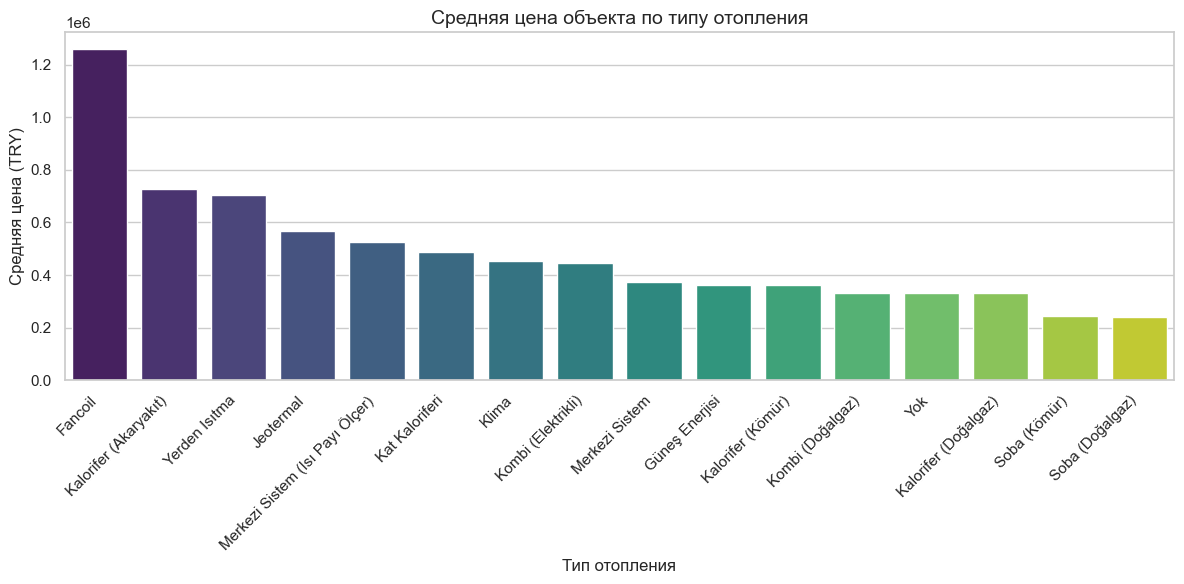

In [17]:
plt.figure(figsize=(12, 6))
mean_prices = df_vis.groupby('heating_type')['price'].mean().sort_values(ascending=False)

sns.barplot(x=mean_prices.index, y=mean_prices.values, hue=mean_prices.index, palette='viridis', legend=False)
plt.title('Средняя цена объекта по типу отопления', fontsize=14)
plt.xlabel('Тип отопления')
plt.ylabel('Средняя цена (TRY)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Тут чётко видно, что тип отопления — это отличный показатель класса жилья. Самые дорогие квартиры идут с системами вроде фанкойлов (Fancoil) и тёплых полов (Yerden Isıtma). А в самом низу ожидаемо самые дешёвые варианты с обычными угольными и газовыми печками (Soba). Чем современнее отопление, тем дороже недвижимость.

## Тепловая карта корреляций

Построим сразу две карты: слева на сырых данных, справа на отфильтрованных. Это хорошо показывает, насколько корреляция Пирсона чувствительна к мусору.

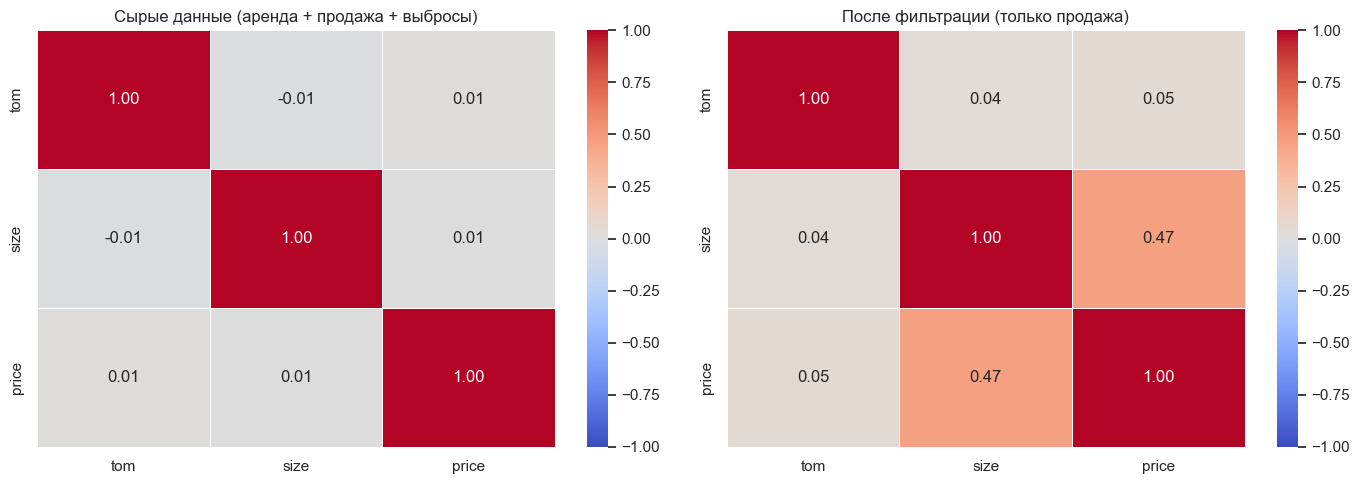

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_raw = df[['tom', 'size', 'price']].corr()
sns.heatmap(corr_raw, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Сырые данные (аренда + продажа + выбросы)')

corr_clean = df_vis[['tom', 'size', 'price']].corr()
sns.heatmap(corr_clean, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('После фильтрации (только продажа)')

plt.tight_layout()
plt.show()

Разница огромная. На сырых данных везде почти нули, и можно было бы решить, что площадь вообще не влияет на цену. А после фильтрации связь площади с ценой сразу становится заметной. Вывод простой: пока данные не вычищены, смотреть на корреляции бесполезно.

Также видно, что `tom` (время на рынке) с ценой почти не связан.

# 1.4 Анализ пропусков и аномалий
Проверяем долю отсутствующих значений, ищем дубликаты и логические ошибки в данных.

## Подсчёт пропусков по столбцам

In [19]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({'Количество пропусков': missing_data,
                           'Доля от всего датасета (%)': missing_percent.round(2)})
display(missing_df)

,Количество пропусков,Доля от всего датасета (%)
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price,715,0.18
price_currency,715,0.18


Колонка с наличием мебели `furnished` пустая на все 100%, её смело удаляем. Площадь `size` и дата закрытия объявления `end_date` отсутствуют больше чем на треть. `end_date` нам не нужна, а вот площадь - ключевой признак, её будем восстанавливать. Пропусков в цене совсем мало (715 строк), эти строки просто выкинем.

## Визуализация пропусков

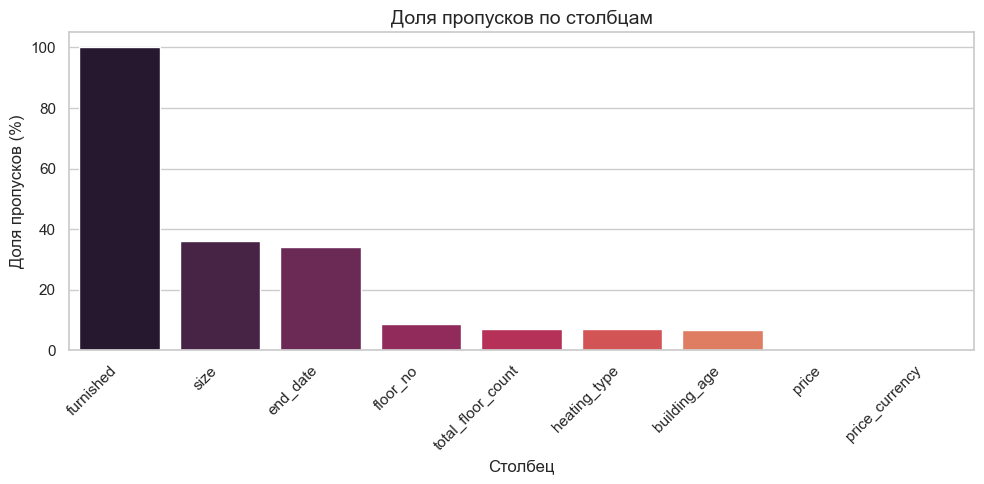

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Доля от всего датасета (%)'],
            hue=missing_df.index, palette='rocket', legend=False)
plt.title('Доля пропусков по столбцам', fontsize=14)
plt.ylabel('Доля пропусков (%)')
plt.xlabel('Столбец')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Проверка на дубликаты

In [21]:
duplicates = df.duplicated().sum()
duplicates_no_id = df.drop(columns=['id']).duplicated().sum()

print(f"Количество полных дубликатов: {duplicates}")
print(f"Количество дубликатов без учёта id: {duplicates_no_id}")

Количество полных дубликатов: 0
Количество дубликатов без учёта id: 11455


Полных дубликатов нет. Без учёта `id` дубликаты появляются, но это нормально: одинаковые квартиры в одном доме вполне могут иметь совпадающие характеристики, это разные объявления, а не ошибка. Удалять их не будем.

## Проверка на логические аномалии

In [22]:
negative_prices = df[df['price'] <= 0].shape[0]
huge_size = df[df['size'] > 10000].shape[0]
tiny_size = df[df['size'] < 10].shape[0]
broken_rooms = df[df['room_count'] == '+'].shape[0]

print(f"Объектов с отрицательной или нулевой ценой: {negative_prices}")
print(f"Объектов с аномальной площадью (> 10 000 кв.м): {huge_size}")
print(f"Объектов с нереально маленькой площадью (< 10 кв.м): {tiny_size}")
print(f"Объектов со сломанной планировкой (room_count = '+'): {broken_rooms}")

Объектов с отрицательной или нулевой ценой: 45
Объектов с аномальной площадью (> 10 000 кв.м): 148
Объектов с нереально маленькой площадью (< 10 кв.м): 389
Объектов со сломанной планировкой (room_count = '+'): 2898


Как и подозревали, в данных есть откровенный мусор: отрицательные цены, квартиры на 950 тысяч квадратов и планировка, записанная одним плюсом. Всё это удалим на этапе очистки.

# 1.5 Промежуточные выводы и гипотезы

В ходе первичного анализа датасета Zingat (403 487 записей) мы получили довольно чёткую картину.

**Что по качеству данных**:
* Главная проблема - смесь аренды и продажи. В `listing_type` лежат два разных типа объявлений, и медианные цены у них отличаются на два порядка. Это и есть основная причина дикой асимметрии (308) и нулевых корреляций. Оставим только продажу.
* Разные валюты. Кроме лир есть доллары, евро и фунты. Их цены в другом масштабе, такие строки удалим.
* Мусор и выбросы: нулевые и отрицательные цены (45 штук), площади больше 10 000 квадратов (148 штук), планировка '+'. Всё вычищаем, а таргет логарифмируем - гистограмма log(price) показала почти нормальную форму.
* Пропуски и бесполезные столбцы: `furnished` пуст на 100%, `type` состоит из одного значения - удаляем. В площади пропусков больше трети, будем восстанавливать медианой по планировке. 715 строк без цены выкидываем.
* Дубликатов нет, полных совпадений строк не нашлось.

**Ключевые гипотезы для модели**:
* Гипотеза 1: Площадь - главный драйвер цены. На диаграмме рассеяния после очистки связь прямая и хорошо заметная, корреляция на чистых данных резко выросла. Ожидаю, что `size` будет самым важным признаком.
* Гипотеза 2: Планировка усиливает площадь, но не заменяет её. Боксплот показал рост цены от студий к большим квартирам, при этом у 2+1 и 3+1 огромный разброс. Значит комнатность объясняет часть цены, но не всю.
* Гипотеза 3: Расположение решает не меньше метража. Разброс цен внутри одной планировки настолько большой, что объяснить его может только район. В адресе 7842 уникальных значения, и если их правильно закодировать, признак должен зайти в топ важности.
* Гипотеза 4: Тип отопления работает как индикатор класса жилья. Средняя цена по фанкойлам и тёплому полу в разы выше, чем по печкам Soba. Прямой связи "отопление -> цена" нет, но косвенно признак сильный.
* Гипотеза 5: Время на рынке (`tom`) для прогноза бесполезно и опасно. Корреляция с ценой близка к нулю, плюс в столбце видны искусственные всплески раз в 30 дней (автопродление объявлений). Плюс к этому, для новой квартиры это значение просто неизвестно. Признак удаляем.

# Этап 2. Предварительная обработка данных (Data Preprocessing)
**Задачи:**
1. Работа с пропусками.
2. Обработка выбросов и аномалий.
3. Feature Engineering (конструирование признаков).
4. Разбиение данных (Train / Test).
5. Кодирование категориальных признаков и масштабирование.
6. Проверка мультиколлинеарности.


# 2.1 Работа с пропусками

Стратегия по каждому столбцу:
* `price` — целевая переменная, восстанавливать её нельзя, поэтому строки без цены удаляем (их всего 0.18%).
* `furnished` — пуст на 100%, столбец удаляем целиком.
* `end_date` — треть пропусков, но признак нам не нужен (он про снятие объявления, а не про объект), удаляем столбец.
* `size` — 36% пропусков, но это ключевой признак, удалять нельзя. Заполним медианой по количеству комнат: у квартир 3+1 своя типичная площадь, у студий своя. Делаем это после сплита, по медианам из train.
* `building_age`, `total_floor_count`, `floor_no`, `heating_type` — категориальные, пропусков около 7-9%. Заполняем словом 'Unknown', чтобы модель воспринимала отсутствие информации как отдельную категорию. Это константа, статистику по данным она не использует, поэтому утечки нет.

In [23]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['price'])

cat_cols_with_na = ['building_age', 'total_floor_count', 'floor_no', 'heating_type']
for col in cat_cols_with_na:
    df_clean[col] = df_clean[col].fillna('Unknown').astype(str)

print(f"Осталось строк после удаления пустых цен: {df_clean.shape[0]}")

Осталось строк после удаления пустых цен: 402772


# 2.2 Обработка выбросов и аномалий

Тут делаем самое главное: оставляем только продажу в лирах и режем нереалистичные значения. Каждый шаг печатаем, чтобы было видно, сколько строк ушло и почему.

Границы:
* цена от 10 000 до 50 000 000 лир — ниже этого для продажи квартиры быть не может, выше это уже штучные дворцы, которые модель всё равно не выучит;
* площадь от 10 до 1000 кв.м;
* планировку '+' выкидываем, из неё ничего не распарсить.


In [24]:
steps = []

before = df_clean.shape[0]
df_clean = df_clean[df_clean['price_currency'] == 'TRY']
steps.append(('Оставили только лиры (TRY)', before - df_clean.shape[0]))

before = df_clean.shape[0]
df_clean = df_clean[df_clean['listing_type'] == SALE_TYPE]
steps.append(('Оставили только продажу', before - df_clean.shape[0]))

before = df_clean.shape[0]
df_clean = df_clean[(df_clean['price'] > 10000) & (df_clean['price'] < 50000000)]
steps.append(('Убрали нереалистичные цены', before - df_clean.shape[0]))

before = df_clean.shape[0]
df_clean = df_clean[df_clean['size'].isna() | ((df_clean['size'] > 10) & (df_clean['size'] < 1000))]
steps.append(('Убрали нереалистичные площади', before - df_clean.shape[0]))

before = df_clean.shape[0]
df_clean = df_clean[df_clean['room_count'] != '+']
steps.append(("Убрали планировку '+'", before - df_clean.shape[0]))

steps_df = pd.DataFrame(steps, columns=['Шаг очистки', 'Удалено строк'])
display(steps_df)
print(f"Итого осталось: {df_clean.shape[0]} строк из {df.shape[0]} ({df_clean.shape[0] / df.shape[0] * 100:.1f}%)")

,Шаг очистки,Удалено строк
0,Оставили только лиры (TRY),2095
1,Оставили только продажу,116181
2,Убрали нереалистичные цены,423
3,Убрали нереалистичные площади,888
4,Убрали планировку '+',1746


Итого осталось: 281439 строк из 403487 (69.8%)


Основная потеря пришлась на аренду. Это не потеря данных, а наоборот приведение выборки к одной задаче: мы предсказываем стоимость покупки, а не аренды.

Отдельно проверим, что смесь ушла и распределение цены стало вменяемым.

In [25]:
print(f"Асимметрия цены после очистки: {df_clean['price'].skew():.2f}")
display(df_clean['price'].describe().round(0))

Асимметрия цены после очистки: 18.76


count      281439.0
mean       442098.0
std       1021899.0
min         10227.0
25%        185000.0
50%        269000.0
75%        415000.0
max      49000000.0
Name: price, dtype: float64

## Логарифмирование целевой переменной

Асимметрия всё ещё есть (рынок недвижимости так устроен: дешёвых квартир много, дорогих мало). Логарифмируем цену, чтобы распределение стало ближе к нормальному. Заодно это меняет смысл ошибки: модель начинает штрафоваться за относительное отклонение, а не за абсолютное, и перестаёт гнаться только за дорогими объектами.

In [26]:
df_clean['price_log'] = np.log1p(df_clean['price'])
print(f"Асимметрия после логарифмирования: {df_clean['price_log'].skew():.2f}")

Асимметрия после логарифмирования: 1.15


# 2.3 Feature Engineering и удаление лишнего

Вытаскиваем новые полезные признаки из существующих и избавляемся от мусора.

Что мы удаляем:
* `furnished` — пуст на 100%
* `type` — имеет только 1 значение
* `id` — просто номер строки, смысла нет
* `price_currency` — после фильтрации там осталось одно значение
* `end_date` — не нужна, к тому же треть пропусков
* `listing_type` — после фильтрации там тоже одно значение
* `tom` (time on market) — удаляем по двум причинам: (1) для новой квартиры, цену которой должна предсказать модель в приложении, это значение физически неизвестно заранее, его нельзя будет заполнить в форме прогноза; (2) это характеристика объявления, а не объекта, использовать её для предсказания цены на момент публикации некорректно.
* `address` и `start_date` — сами по себе не нужны, но из них мы вытащим новые признаки.

Что мы создаём:
* `city` — город из адреса.
* `district` — город + округ (первые две части адреса). Полный адрес слишком дробный (7842 значения), а один город слишком грубый.
* `rooms` и `living_rooms` — раскладываем "3+1" на два числа. Так модель видит планировку как числа, а не как 37 отдельных категорий.
* `is_ground_floor` и `is_top_floor` — флаги первого и последнего этажа. Это известный фактор цены, и из текстовых категорий турецких этажей его иначе не достать.
* `list_month` и `list_year` — месяц и год публикации, чтобы поймать сезонность и инфляцию.

Признак `price_per_sqm` (цена за метр) специально не делаем: он считается из цены, и модель просто подсмотрела бы через него ответ. Это была бы прямая утечка.

## Вытаскиваем город и округ из адреса

In [27]:
df_clean['city'] = df_clean['address'].str.split('/').str[0]
df_clean['district'] = df_clean['address'].str.split('/').str[:2].str.join('/')

print(f"Уникальных городов: {df_clean['city'].nunique()}")
print(f"Уникальных округов: {df_clean['district'].nunique()}")
print(f"Уникальных полных адресов было: {df_clean['address'].nunique()}")

Уникальных городов: 82
Уникальных округов: 561
Уникальных полных адресов было: 7332


## Раскладываем планировку на числа

In [28]:
rooms_split = df_clean['room_count'].str.extract(r'(\d+)\+(\d+)')
df_clean['rooms'] = pd.to_numeric(rooms_split[0], errors='coerce')
df_clean['living_rooms'] = pd.to_numeric(rooms_split[1], errors='coerce')

df_clean['rooms'] = df_clean['rooms'].fillna(df_clean['rooms'].median())
df_clean['living_rooms'] = df_clean['living_rooms'].fillna(df_clean['living_rooms'].median())
df_clean['total_rooms'] = df_clean['rooms'] + df_clean['living_rooms']

display(df_clean[['room_count', 'rooms', 'living_rooms', 'total_rooms']].head())

,room_count,rooms,living_rooms,total_rooms
1,1+0,1,0,1
2,2+1,2,1,3
3,6+1,6,1,7
4,2+1,2,1,3
5,1+1,1,1,2


## Флаги первого и последнего этажа

In [29]:
ground_floor_labels = ['Zemin Kat', 'Giriş Katı', 'Yüksek Giriş', 'Bahçe katı']
top_floor_labels = ['Çatı Katı', 'En Üst Kat', 'Teras Kat']

df_clean['is_ground_floor'] = df_clean['floor_no'].isin(ground_floor_labels).astype(int)
df_clean['is_top_floor'] = df_clean['floor_no'].isin(top_floor_labels).astype(int)

print(f"Объектов на первом/цокольном этаже: {df_clean['is_ground_floor'].sum()}")
print(f"Объектов на последнем этаже/мансарде: {df_clean['is_top_floor'].sum()}")

Объектов на первом/цокольном этаже: 40945
Объектов на последнем этаже/мансарде: 3203


## Месяц и год публикации

In [30]:
df_clean['start_date'] = pd.to_datetime(df_clean['start_date'], format='%m/%d/%y', errors='coerce')
df_clean['list_month'] = df_clean['start_date'].dt.month
df_clean['list_year'] = df_clean['start_date'].dt.year

display(df_clean[['list_year', 'list_month']].value_counts().sort_index())

list_year  list_month
2018       8              1914
           9             56897
           10            64352
           11            53758
           12            40099
2019       1             32691
           2             31728
Name: count, dtype: int64

## Удаляем ненужные столбцы

In [31]:
cols_to_drop = ['id', 'type', 'furnished', 'price_currency', 'end_date', 'tom',
                'listing_type', 'address', 'start_date', 'room_count']
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Осталось столбцов: {df_clean.shape[1]}")
display(df_clean.head(3))

Осталось столбцов: 17


,sub_type,building_age,total_floor_count,floor_no,size,heating_type,price,price_log,city,district,rooms,living_rooms,total_rooms,is_ground_floor,is_top_floor,list_month,list_year
1,Daire,0,20 ve üzeri,20 ve üzeri,43.0,Fancoil,490000.0,13.102163,İstanbul,İstanbul/Kartal,1,0,1,0,0,2,2019
2,Daire,0,1,Yüksek Giriş,NaN,Fancoil,155000.0,11.951187,Tekirdağ,Tekirdağ/Çorlu,2,1,3,1,0,10,2018
3,Rezidans,3,20 ve üzeri,20 ve üzeri,450.0,Fancoil,32500000.0,17.296751,İstanbul,İstanbul/Beşiktaş,6,1,7,0,0,9,2018


# 2.4 Корреляции после очистки

В EDA матрица корреляций была бесполезной, потому что данные были грязные и почти все признаки лежали как текст. Теперь пересчитаем её нормально. Для этого временно переведём текстовые порядковые признаки в числа (возьмём середину диапазона).

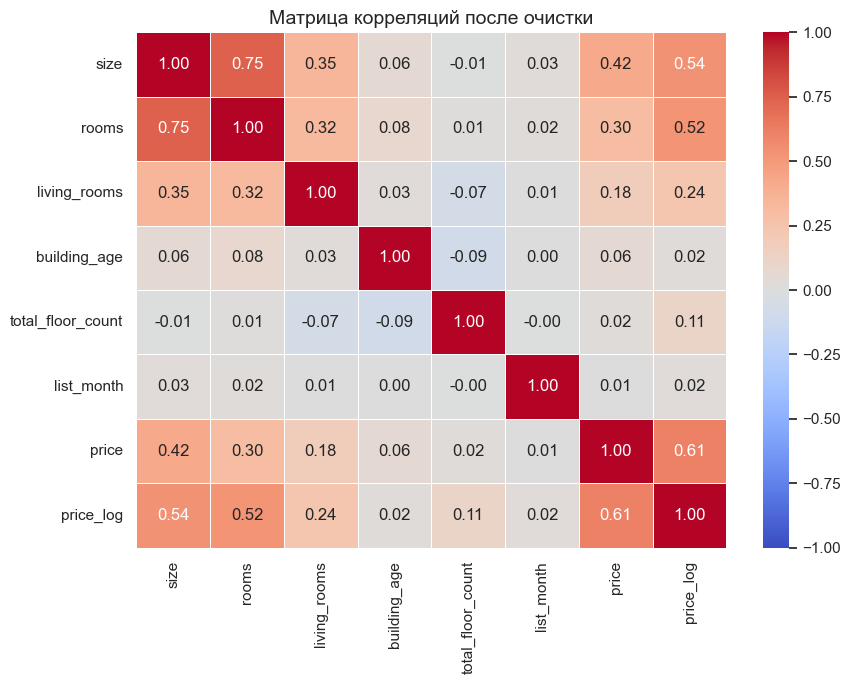

In [32]:
def range_to_number(value):
    text = str(value)
    numbers = re.findall(r'\d+', text)
    if not numbers:
        return np.nan
    return sum(float(n) for n in numbers) / len(numbers)


corr_frame = pd.DataFrame({
    'size': df_clean['size'],
    'rooms': df_clean['rooms'],
    'living_rooms': df_clean['living_rooms'],
    'building_age': df_clean['building_age'].apply(range_to_number),
    'total_floor_count': df_clean['total_floor_count'].apply(range_to_number),
    'list_month': df_clean['list_month'],
    'price': df_clean['price'],
    'price_log': df_clean['price_log'],
})

plt.figure(figsize=(9, 7))
sns.heatmap(corr_frame.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матрица корреляций после очистки', fontsize=14)
plt.tight_layout()
plt.show()

Теперь картина адекватная. Площадь и комнатность заметно связаны с ценой, причём с логарифмом цены связь сильнее, чем с сырой ценой — ещё один аргумент в пользу логарифмирования. Гипотеза 1 подтверждается.

Также видно, что `size`, `rooms` и `living_rooms` сильно связаны между собой (что логично: чем больше комнат, тем больше метров). Это первый звоночек про мультиколлинеарность, формально проверим её через VIF ниже.

# 2.5 Разбиение данных

Отделяем цену от признаков и делим на train/test в пропорции 80/20. `random_state` фиксируем, чтобы разбиение было одинаковым при каждом запуске. Подбор гиперпараметров дальше будем делать кросс-валидацией внутри train, а test трогаем только один раз в самом конце.

Обучаем модель предсказывать `price_log`, поэтому таргетом берём именно его. Обычную `price` из признаков убираем обязательно, иначе это была бы прямая утечка.

In [33]:
X = df_clean.drop(columns=['price', 'price_log'])
y = df_clean['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train = X_train.copy()
X_test = X_test.copy()

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки:  {X_test.shape[0]} строк")

Размер обучающей выборки: 225151 строк
Размер тестовой выборки:  56288 строк


# 2.6 Заполнение площади и признаки, считающиеся по train

Тут собраны все преобразования, которые используют статистику по данным. Все они считаются на train и применяются к test как готовые числа.

Площадь. Заполняем медианой по количеству комнат: если у нас пустая площадь для 3+1, берём медиану именно квартир 3+1, а не среднее по больнице. Если планировка совсем редкая и медианы для неё нет, добиваем общей медианой.

In [34]:
size_medians = X_train.groupby('total_rooms')['size'].median()
size_median_global = X_train['size'].median()

for part in (X_train, X_test):
    part['size'] = part['size'].fillna(part['total_rooms'].map(size_medians))
    part['size'] = part['size'].fillna(size_median_global)

print(f"Пропусков в size (train): {X_train['size'].isna().sum()}")
print(f"Пропусков в size (test):  {X_test['size'].isna().sum()}")

Пропусков в size (train): 0
Пропусков в size (test):  0


## Логарифм площади и площадь на комнату

Площадь тоже скошена вправо, логарифмируем её по той же причине, что и цену. Плюс делаем признак "сколько метров приходится на комнату" — он отличает просторную планировку от тесной при одинаковом числе комнат.

In [35]:
for part in (X_train, X_test):
    part['size_log'] = np.log1p(part['size'])
    part['size_per_room'] = part['size'] / part['total_rooms']

display(X_train[['size', 'size_log', 'total_rooms', 'size_per_room']].describe().round(2))

,size,size_log,total_rooms,size_per_room
count,225151.00,225151.00,225151.00,225151.00
mean,125.50,4.76,3.77,32.65
std,60.68,0.39,1.13,9.73
min,11.00,2.48,1.00,2.75
25%,90.00,4.51,3.00,30.00
50%,120.00,4.80,4.00,32.50
75%,140.00,4.95,4.00,35.00
max,999.00,6.91,14.00,730.00


## Кодирование района средней ценой

У `district` больше тысячи значений. One-Hot тут не подходит: получилась бы тысяча столбцов, модель бы распухла и переобучилась на редких районах. Поэтому используем среднее (целевое) кодирование, которое как раз рекомендуется для признаков с большим количеством категорий: заменяем название района на среднюю логарифмическую цену по нему.

Два важных момента:
1. Среднее считаем только по train, иначе информация о ценах теста утекла бы в признак.
2. Добавляем сглаживание: если в районе всего пара объявлений, его среднее ненадёжно, поэтому подмешиваем к нему общее среднее по выборке. Чем меньше объявлений в районе, тем сильнее значение притягивается к общему среднему.

Районы, которых не было в train, получают общее среднее.

In [36]:
SMOOTHING = 20
global_mean_price_log = y_train.mean()

district_stats = y_train.groupby(X_train['district']).agg(['mean', 'count'])
district_price_map = ((district_stats['mean'] * district_stats['count'] + global_mean_price_log * SMOOTHING)
                      / (district_stats['count'] + SMOOTHING))

for part in (X_train, X_test):
    part['district_price'] = part['district'].map(district_price_map).fillna(global_mean_price_log)

print(f"Закодировано районов: {len(district_price_map)}")
display(district_price_map.sort_values(ascending=False).head(5).round(3))

Закодировано районов: 544


district
İstanbul/Beşiktaş    14.730
İstanbul/Sarıyer     14.600
İstanbul/Bakırköy    14.170
İstanbul/Beykoz      14.104
İzmir/Çeşme          14.037
dtype: float64

Сверху ожидаемо оказались центральные округа крупных городов. Гипотеза 3 про важность расположения начинает подтверждаться, окончательно проверим её по важности признаков.

# 2.7 Кодирование категориальных признаков и масштабирование

Делим признаки на три группы:
* **Числовые** — масштабируем `StandardScaler`. Для линейной модели это обязательно (иначе признак с большими значениями перетянет одеяло на себя), деревьям всё равно, но одинаковый препроцессинг для всех моделей делает сравнение честным.
* **Порядковые** (`building_age`, `total_floor_count`, `floor_no`) — тут категории имеют естественный порядок ("0-5 лет" младше "11-15 лет"), поэтому One-Hot их бы испортил, теряется порядок. Берём `OrdinalEncoder` с явно заданным порядком категорий.
* **Номинальные** (`sub_type`, `heating_type`, `city`) — порядка нет, берём One-Hot. Редкие категории (реже 100 раз) кодировщик сам сгруппирует в одну общую, чтобы не плодить бесполезные столбцы.

In [37]:
num_features = ['size_log', 'size_per_room', 'rooms', 'living_rooms',
                'district_price', 'is_ground_floor', 'is_top_floor',
                'list_month', 'list_year']
ordinal_features = ['building_age', 'total_floor_count', 'floor_no']
nominal_features = ['sub_type', 'heating_type', 'city']

for col in ordinal_features + nominal_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print(f"Числовых признаков: {len(num_features)}")
print(f"Порядковых признаков: {len(ordinal_features)}")
print(f"Номинальных признаков: {len(nominal_features)}")

Числовых признаков: 9
Порядковых признаков: 3
Номинальных признаков: 3


## Задаём правильный порядок для порядковых признаков

Тут самое тонкое место. Категории записаны по-турецки, и порядок надо задать руками, иначе кодировщик расставит их по алфавиту и получится ерунда.

Для `building_age` и `total_floor_count` порядок берём по числам внутри строки: у диапазона типа '11-15 arası' берём середину (13), у '40 ve üzeri' берём 40, у обычного числа само число. 'Unknown' отправляем в конец.

Для `floor_no` числами не обойтись: там есть подвалы ('Bodrum Kat', 'Kot 1'), уровень входа ('Zemin Kat', 'Giriş Katı') и мансарда ('Çatı Katı'). Для них прописываем порядок вручную: подвалы уходят в минус, вход около нуля, мансарда и последний этаж наверх.

In [38]:
floor_manual_order = {
    'Kot 4': -4, 'Kot 3': -3, 'Bodrum Kat': -3, 'Kot 2': -2, 'Kot 1': -1,
    'Bahçe katı': -0.5, 'Zemin Kat': 0, 'Giriş Katı': 0.1, 'Yüksek Giriş': 0.2,
    'Müstakil': 0.3, 'Komple': 0.4, 'Asma Kat': 0.5,
    '20 ve üzeri': 20, 'Çatı Katı': 21, 'Teras Kat': 22, 'En Üst Kat': 23,
    'Unknown': 999,
}


def range_sort_key(value):
    text = str(value).strip()
    if text.lower() in ('unknown', 'nan', 'none', ''):
        return 999
    numbers = re.findall(r'\d+', text)
    if not numbers:
        return 999
    return sum(float(n) for n in numbers) / len(numbers)


def floor_sort_key(value):
    text = str(value).strip()
    if text in floor_manual_order:
        return floor_manual_order[text]
    return range_sort_key(text)


sort_keys = {'building_age': range_sort_key,
             'total_floor_count': range_sort_key,
             'floor_no': floor_sort_key}

ordinal_categories = []
for col in ordinal_features:
    categories = sorted(X_train[col].unique().tolist(), key=sort_keys[col])
    ordinal_categories.append(categories)
    print(f"{col}:\n  {categories}\n")

building_age:
  ['0', '1', '2', '3', '4', '5', '6-10 arası', '11-15 arası', '16-20 arası', '21-25 arası', '26-30 arası', '31-35 arası', '36-40 arası', '40 ve üzeri', 'Unknown']

total_floor_count:
  ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '10-20 arası', '20 ve üzeri', 'Unknown']

floor_no:
  ['Kot 4', 'Bodrum Kat', 'Kot 3', 'Kot 2', 'Kot 1', 'Bahçe katı', 'Zemin Kat', 'Giriş Katı', 'Yüksek Giriş', 'Müstakil', 'Komple', 'Asma Kat', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20 ve üzeri', 'Çatı Katı', 'Teras Kat', 'En Üst Kat', 'Unknown']



Порядок теперь читается нормально: возраст здания идёт от 0 к '40 ve üzeri', этажность по возрастанию, а этажи начинаются с подвалов и заканчиваются мансардой. 'Unknown' стоит в конце как отдельная категория.

(В прошлой версии тут была ошибка: регулярка ловила дефис в '11-15' как минус и все диапазоны получали одинаковый ключ, из-за чего порядок был случайным.)

## Собираем ColumnTransformer

In [39]:
def build_preprocessor(numeric_cols):
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1), ordinal_features),
        ('nom', OneHotEncoder(handle_unknown='infrequent_if_exist',
                              min_frequency=100,
                              sparse_output=False), nominal_features),
    ])


def get_feature_names(fitted_preprocessor, numeric_cols):
    nominal_names = fitted_preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_features)
    return numeric_cols + ordinal_features + list(nominal_names)


preprocessor = build_preprocessor(num_features)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
all_feature_names = get_feature_names(preprocessor, num_features)

print(f"Размер обучающей выборки (train): {X_train_processed.shape}")
print(f"Размер тестовой выборки (test):  {X_test_processed.shape}")

Размер обучающей выборки (train): (225151, 101)
Размер тестовой выборки (test):  (56288, 101)


Обратите внимание: `fit_transform` вызывается только на train, а к test применяется уже обученный препроцессор через `transform`. Так среднее и дисперсия скейлера, список категорий кодировщиков — всё считается по обучающей выборке, и утечки нет.

# 2.8 Проверяем мультиколлинеарность (VIF)

VIF показывает, не дублируют ли признаки друг друга. Считаем только для числовых и порядковых признаков: для One-Hot столбцов VIF смысла не имеет, там дамми-переменные одной категории связаны между собой по построению.

Важная деталь: в матрицу добавляем константу, иначе statsmodels считает VIF без свободного члена и завышает значения. Если VIF выше 10, признаки слишком похожи и один из них надо убирать.

In [40]:
def calc_vif(processed_matrix, columns):
    frame = pd.DataFrame(processed_matrix[:, :len(columns)], columns=columns)
    frame = add_constant(frame)
    result = pd.DataFrame({'feature': frame.columns})
    result['VIF'] = [variance_inflation_factor(frame.values, i) for i in range(frame.shape[1])]
    result = result[result['feature'] != 'const']
    return result.sort_values('VIF', ascending=False).round(2)


vif_before = calc_vif(X_train_processed, num_features + ordinal_features)
display(vif_before)

,feature,VIF
9,list_year,15.43
8,list_month,15.43
1,size_log,9.96
3,rooms,6.73
2,size_per_room,2.57
12,floor_no,1.81
11,total_floor_count,1.35
6,is_ground_floor,1.26
4,living_rooms,1.21
10,building_age,1.13


## Убираем лишний признак и пересчитываем

`list_year` и `list_month` дают высокий VIF: датасет покрывает всего около полугода на стыке 2018 и 2019, поэтому год и месяц почти однозначно определяют друг друга. Год при этом менее полезен (в нём всего два значения), так что убираем именно его и оставляем месяц как индикатор сезонности.

После удаления пересобираем препроцессор заново и проверяем VIF ещё раз.

In [41]:
num_features = [col for col in num_features if col != 'list_year']

preprocessor = build_preprocessor(num_features)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
all_feature_names = get_feature_names(preprocessor, num_features)

vif_after = calc_vif(X_train_processed, num_features + ordinal_features)
display(vif_after)
print(f"Итоговое число признаков: {X_train_processed.shape[1]}")

,feature,VIF
1,size_log,9.95
3,rooms,6.73
2,size_per_room,2.56
11,floor_no,1.81
10,total_floor_count,1.35
6,is_ground_floor,1.26
4,living_rooms,1.21
9,building_age,1.13
7,is_top_floor,1.12
5,district_price,1.02


Итоговое число признаков: 100


Теперь все значения в пределах нормы. Признаки `size_log`, `rooms` и `size_per_room` связаны между собой, но не настолько, чтобы их выкидывать: каждый несёт свой смысл (общий метраж, количество комнат и просторность), а VIF остаётся в допустимых рамках.

Данные готовы, можно обучать модели.

# Этап 3. Построение модели регрессии

**Выбор моделей.** Берём три модели принципиально разной природы, чтобы сравнение было содержательным:
1. **Линейная** — линейная модель с L2-регуляризацией. Простая, быстрая, полностью интерпретируемая (есть явные коэффициенты). Будет нашей базовой точкой отсчёта.
2. **Random Forest** — ансамбль на основе бэггинга. Много независимых деревьев, усреднение их ответов. Хорошо ловит нелинейности и взаимодействия признаков.
3. **Ансамблевая модель (бустинг)** — ансамбль на основе бустинга. Деревья строятся последовательно, каждое исправляет ошибки предыдущих. Обычно самый точный вариант, при этом гистограммная версия работает быстро на больших выборках.

## 3.1 & 3.2 Обучение и подбор гиперпараметров

Для Ridge сетка маленькая (4 значения), поэтому перебираем её целиком через `GridSearchCV`. Для леса и бустинга полный перебор считался бы часами, поэтому берём `RandomizedSearchCV`: он пробует случайные комбинации из сетки и работает в разы быстрее.

Везде кросс-валидация на 3 фолда **внутри train**. Метрика для отбора — RMSE по логарифму цены (чем меньше, тем лучше). Тестовую выборку на этом этапе не трогаем вообще.

Сетки специально сделаны широкими: если лучшие параметры окажутся на краю сетки, это значит, что сетку надо расширять дальше, проверим это после обучения.

## Линейная модель 

In [47]:
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 300.0]}

ridge_search = GridSearchCV(Ridge(random_state=RANDOM_STATE),
                            ridge_params,
                            cv=3,
                            scoring='neg_root_mean_squared_error',
                            n_jobs=-1)
ridge_search.fit(X_train_processed, y_train)
best_ridge = ridge_search.best_estimator_

print(f"Лучшие параметры: {ridge_search.best_params_}")
print(f"CV RMSE (log): {-ridge_search.best_score_:.4f}")

Лучшие параметры: {'alpha': 10.0}
CV RMSE (log): 0.4003


## Random Forest

Самая долгая ячейка в ноутбуке, на полном датасете может считаться 15-30 минут. Если нужно быстрее, уменьшите `n_estimators` до 50 и `n_iter` до 2.

In [48]:
rf_params = {
    'n_estimators': [100],
    'max_depth': [15, 25],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 0.5],
}

rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                               rf_params,
                               n_iter=4,
                               cv=3,
                               scoring='neg_root_mean_squared_error',
                               random_state=RANDOM_STATE)
rf_search.fit(X_train_processed, y_train)
best_rf = rf_search.best_estimator_

print(f"Лучшие параметры: {rf_search.best_params_}")
print(f"CV RMSE (log): {-rf_search.best_score_:.4f}")

Лучшие параметры: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 25}
CV RMSE (log): 0.3334


## Ансамблевая модель (бустинг)

In [49]:
hgb_params = {
    'learning_rate': [0.05, 0.1],
    'max_leaf_nodes': [31, 63],
    'min_samples_leaf': [20, 50],
    'l2_regularization': [0.0, 1.0],
}

hgb = HistGradientBoostingRegressor(random_state=RANDOM_STATE,
                                    max_iter=400,
                                    early_stopping=True,
                                    n_iter_no_change=15,
                                    validation_fraction=0.1)

hgb_search = RandomizedSearchCV(hgb,
                                hgb_params,
                                n_iter=4,
                                cv=3,
                                scoring='neg_root_mean_squared_error',
                                random_state=RANDOM_STATE)
hgb_search.fit(X_train_processed, y_train)
best_hgb = hgb_search.best_estimator_

print(f"Лучшие параметры: {hgb_search.best_params_}")
print(f"Деревьев построено до остановки: {best_hgb.n_iter_} из 400")
print(f"CV RMSE (log): {-hgb_search.best_score_:.4f}")

Лучшие параметры: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'learning_rate': 0.1, 'l2_regularization': 1.0}
Деревьев построено до остановки: 400 из 400
CV RMSE (log): 0.3262


## Сравниваем модели по кросс-валидации

Выбор лучшей модели делаем именно здесь, по результатам кросс-валидации на train. Если выбирать победителя по тесту, тест перестаёт быть честной отложенной выборкой: мы бы подглядели в него при принятии решения, и итоговые метрики оказались бы завышенными.

In [50]:
searches = {'Ridge': ridge_search, 'Random Forest': rf_search, 'Gradient Boosting': hgb_search}
models = {name: search.best_estimator_ for name, search in searches.items()}

cv_results = pd.DataFrame({
    'Model': list(searches.keys()),
    'CV RMSE (log)': [-s.best_score_ for s in searches.values()],
    'Лучшие параметры': [str(s.best_params_) for s in searches.values()],
}).set_index('Model')

display(cv_results.round(4))

best_model_name = cv_results['CV RMSE (log)'].idxmin()
best_model = models[best_model_name]
print(f"Лучшая модель по кросс-валидации: {best_model_name}")

,CV RMSE (log),Лучшие параметры
Model,,
Ridge,0.4003,{'alpha': 10.0}
Random Forest,0.3334,"{'n_estimators': 100, 'min_samples_leaf': 10, ..."
Gradient Boosting,0.3262,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,..."


Лучшая модель по кросс-валидации: Gradient Boosting


## Проверяем, не упёрлись ли параметры в край сетки

Если лучшее значение параметра оказалось крайним в списке, значит оптимум может лежать за пределами сетки и её стоит расширить. Это частая ошибка: модель выглядит настроенной, а на деле просто недоучена. Проверяем только те параметры, у которых в сетке больше двух вариантов (для выбора из двух значений край не о чём не говорит).

In [51]:
for name, search in searches.items():
    grid = search.param_distributions if hasattr(search, 'param_distributions') else search.param_grid
    for param, best_value in search.best_params_.items():
        values = grid[param]
        if len(values) > 2 and best_value in (values[0], values[-1]):
            print(f"{name}: параметр '{param}' = {best_value} стоит на краю сетки {values}")
print("Проверка завершена")

Проверка завершена


# 3.3 Метрики качества

Наши модели предсказывали логарифм цены. Чтобы получить понятные метрики в реальных лирах, применяем обратное преобразование `np.expm1` к предсказаниям и к тестовым значениям.

Считаем 5 метрик:
* **MAE** — средняя абсолютная ошибка в лирах, самая понятная метрика.
* **RMSE** — тоже в лирах, но сильнее штрафует крупные промахи.
* **MAPE** — средняя ошибка в процентах, удобна тем, что не зависит от масштаба цены.
* **MedAE** — медианная абсолютная ошибка, показывает типичную ошибку без влияния единичных дорогих объектов.
* **R²** — доля объяснённой дисперсии, считаем и в лирах, и в логарифмах.

Одно честное замечание: `expm1` от предсказанного логарифма даёт не среднюю, а медианную цену, поэтому прогноз в лирах систематически чуть занижен. Для нашей задачи это некритично, но знать об этом надо.

In [52]:
def evaluate_model(model, X_processed, y_log, model_name):
    pred_log = model.predict(X_processed)
    pred_real = np.expm1(pred_log)
    y_real = np.expm1(y_log)

    metrics = {
        'Model': model_name,
        'MAE': mean_absolute_error(y_real, pred_real),
        'RMSE': np.sqrt(mean_squared_error(y_real, pred_real)),
        'MAPE (%)': mean_absolute_percentage_error(y_real, pred_real) * 100,
        'MedAE': median_absolute_error(y_real, pred_real),
        'R2': r2_score(y_real, pred_real),
        'R2 (log)': r2_score(y_log, pred_log),
    }
    return metrics, pred_real, y_real

## Считаем метрики на тесте

In [53]:
results = []
predictions_dict = {}

for name, model in models.items():
    metrics, pred_real, y_test_real = evaluate_model(model, X_test_processed, y_test, name)
    results.append(metrics)
    predictions_dict[name] = pred_real

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(2))

best_preds = predictions_dict[best_model_name]
print(f"Модель, выбранная по кросс-валидации: {best_model_name}")

,MAE,RMSE,MAPE (%),MedAE,R2,R2 (log)
Model,,,,,,
Ridge,161959.52,816246.31,30.94,53828.31,0.36,0.70
Random Forest,130297.21,727949.19,23.58,40116.54,0.49,0.80
Gradient Boosting,128202.76,672443.29,23.96,42578.87,0.57,0.81


Модель, выбранная по кросс-валидации: Gradient Boosting


# 3.4 Сравнение моделей

Строим графики: сравнение метрик, "предсказание против факта", распределение остатков и важность признаков.

## Визуализация 1: Сравнение метрик

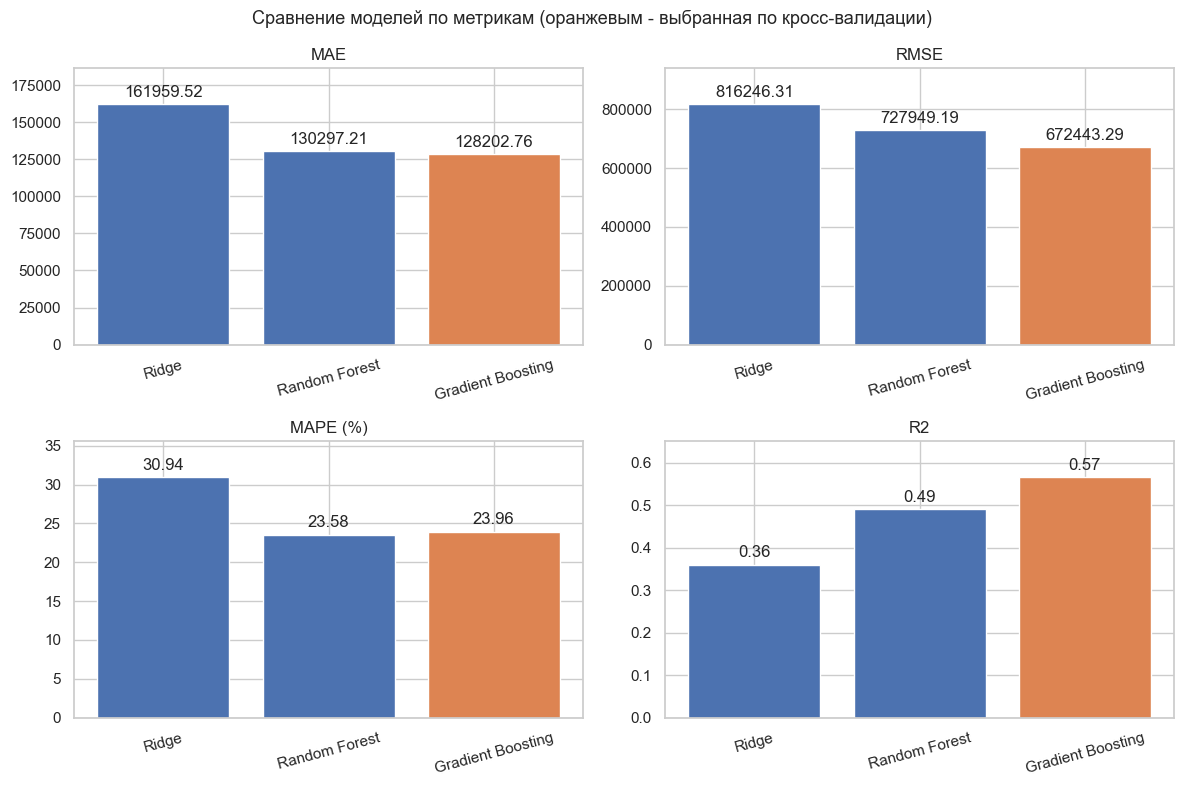

In [54]:
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in results_df.index]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(results_df.index, results_df[metric], color=colors)
    ax.set_title(metric)
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.margins(y=0.15)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Сравнение моделей по метрикам (оранжевым - выбранная по кросс-валидации)', fontsize=13)
plt.tight_layout()
plt.show()

## Визуализация 2: Предсказание против факта и остатки

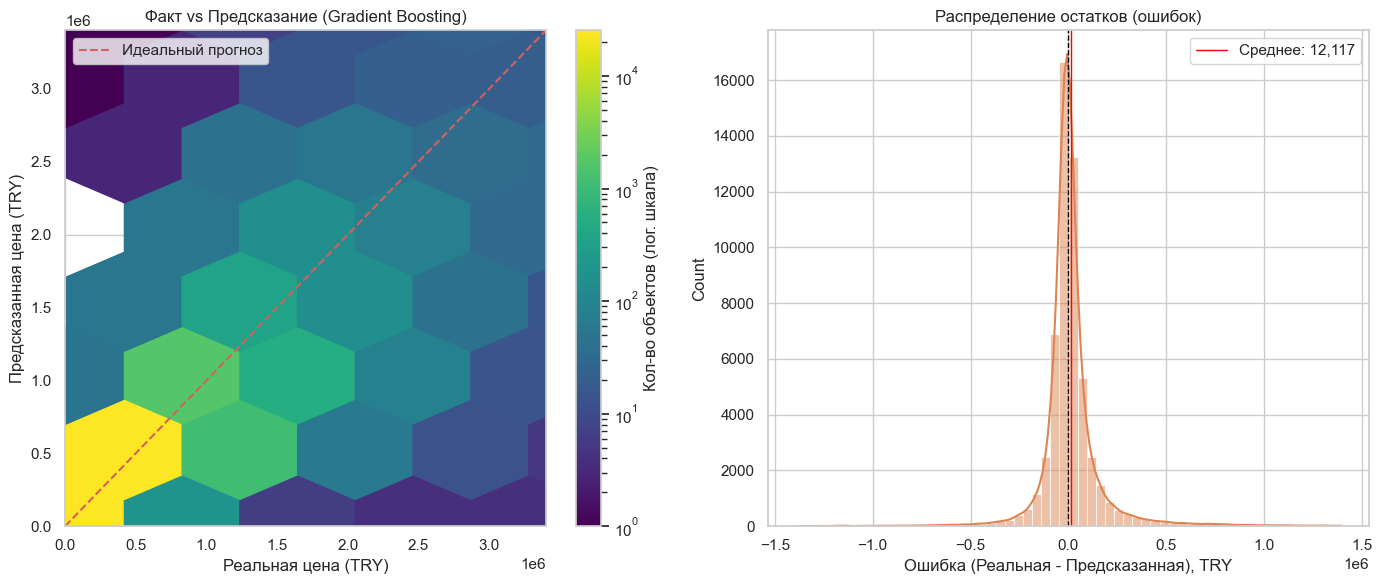

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hb = axes[0].hexbin(y_test_real, best_preds, gridsize=60, cmap='viridis', mincnt=1, bins='log')
lims = [0, np.percentile(y_test_real, 99)]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Идеальный прогноз')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title(f'Факт vs Предсказание ({best_model_name})')
axes[0].set_xlabel('Реальная цена (TRY)')
axes[0].set_ylabel('Предсказанная цена (TRY)')
axes[0].legend()
fig.colorbar(hb, ax=axes[0], label='Кол-во объектов (лог. шкала)')

residuals = y_test_real - best_preds
resid_clip = residuals[np.abs(residuals) < np.percentile(np.abs(residuals), 99)]
sns.histplot(resid_clip, bins=60, kde=True, color='#DD8452', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(resid_clip.mean(), color='red', linestyle='-', linewidth=1,
                label=f'Среднее: {resid_clip.mean():,.0f}')
axes[1].set_title('Распределение остатков (ошибок)')
axes[1].set_xlabel('Ошибка (Реальная - Предсказанная), TRY')
axes[1].legend()

plt.tight_layout()
plt.show()

**График 1: Факт vs Предсказание.** Чем плотнее точки жмутся к красной линии, тем лучше модель. Вместо обычных точек тут hexbin (шестиугольники), потому что при таком количестве строк обычный scatter превращается в одно сплошное пятно и ничего не видно.

**График 2: Остатки.** Если ошибки распределены вокруг нуля симметрично, модель не занижает и не завышает цену систематически. Смещение среднего влево ожидаемо: это как раз тот эффект обратного логарифмирования, о котором писали выше.

## Визуализация 3: Важность признаков

Для важности используем permutation importance: мы перемешиваем значения одного признака и смотрим, насколько просядет R². Такой способ работает с любой моделью (у бустинга `feature_importances_` вообще нет), поэтому он честно применяется именно к выбранной модели, а не к какой-то другой.

Считаем на подвыборке из теста, чтобы не ждать слишком долго.

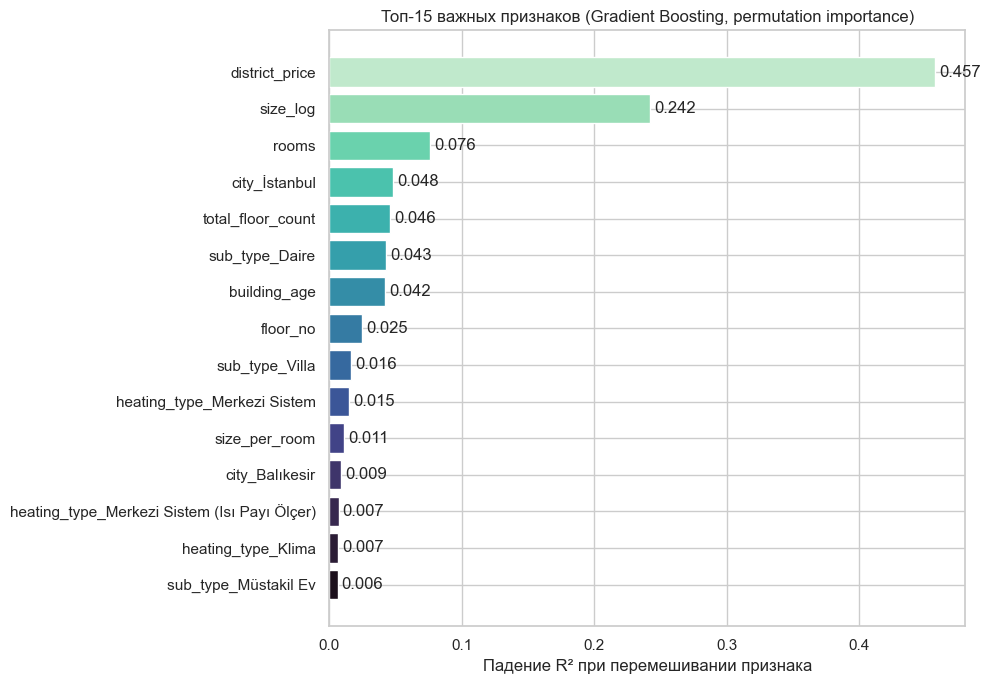

In [56]:
sample_size = min(5000, X_test_processed.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_test_processed.shape[0], size=sample_size, replace=False)

perm = permutation_importance(best_model,
                              X_test_processed[sample_idx],
                              y_test.iloc[sample_idx],
                              n_repeats=3,
                              random_state=RANDOM_STATE,
                              scoring='r2',
                              n_jobs=-1)

importance_df = pd.DataFrame({'feature': all_feature_names,
                              'importance': perm.importances_mean}).sort_values('importance', ascending=False)

top_n = 15
top = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
colors = sns.color_palette('mako', n_colors=top_n)
bars = plt.barh(top['feature'], top['importance'], color=colors)
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.title(f'Топ-{top_n} важных признаков ({best_model_name}, permutation importance)')
plt.xlabel('Падение R² при перемешивании признака')
plt.tight_layout()
plt.show()

## Коэффициенты линейной модели

У Ridge есть явные коэффициенты, и это её главное преимущество: видно не только силу влияния признака, но и знак. Признаки отмасштабированы, поэтому коэффициенты можно сравнивать между собой напрямую.

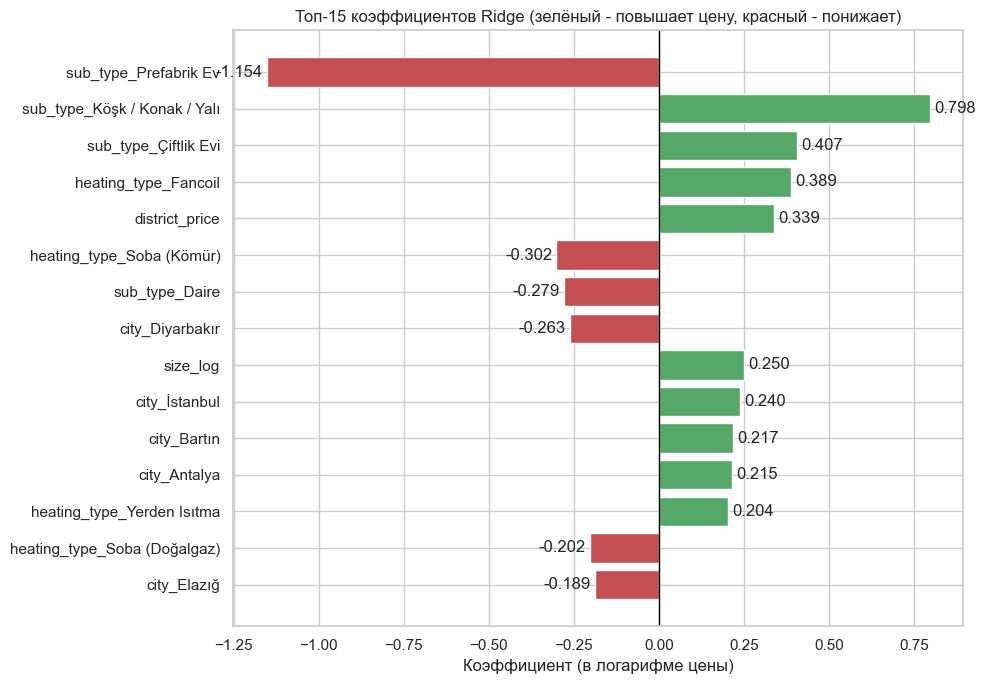

In [57]:
coef_df = pd.DataFrame({'feature': all_feature_names,
                        'coef': best_ridge.coef_})
coef_df['abs_coef'] = coef_df['coef'].abs()
top_coef = coef_df.sort_values('abs_coef', ascending=False).head(15).iloc[::-1]

plt.figure(figsize=(10, 7))
bar_colors = ['#C44E52' if c < 0 else '#55A868' for c in top_coef['coef']]
bars = plt.barh(top_coef['feature'], top_coef['coef'], color=bar_colors)
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.axvline(0, color='black', linewidth=1)
plt.title('Топ-15 коэффициентов Ridge (зелёный - повышает цену, красный - понижает)')
plt.xlabel('Коэффициент (в логарифме цены)')
plt.tight_layout()
plt.show()

# 3.5 Проверка на переобучение

Метрики на тесте это ещё не всё. Посчитаем те же метрики на train и сравним. Если на train намного лучше, чем на test, модель переобучилась и запомнила обучающую выборку вместо того, чтобы выучить закономерности.

In [58]:
train_results = []
for name, model in models.items():
    metrics_train, _, _ = evaluate_model(model, X_train_processed, y_train, name)
    train_results.append(metrics_train)

train_results_df = pd.DataFrame(train_results).set_index('Model')

comparison_df = pd.DataFrame({
    'MAPE train (%)': train_results_df['MAPE (%)'],
    'MAPE test (%)': results_df['MAPE (%)'],
    'R2 train (log)': train_results_df['R2 (log)'],
    'R2 test (log)': results_df['R2 (log)'],
})
comparison_df['Разрыв MAPE'] = comparison_df['MAPE test (%)'] - comparison_df['MAPE train (%)']
display(comparison_df.round(3))

,MAPE train (%),MAPE test (%),R2 train (log),R2 test (log),Разрыв MAPE
Model,,,,,
Ridge,31.018,30.937,0.699,0.700,-0.081
Random Forest,20.885,23.578,0.841,0.804,2.692
Gradient Boosting,22.461,23.955,0.829,0.805,1.495


Смотрим на столбец "Разрыв MAPE": чем он больше, тем сильнее модель подстроилась под обучающую выборку. У Ridge разрыв обычно минимальный (модель простая, ей нечем переобучаться), у ансамблей больше. Небольшой разрыв это норма, тревожный сигнал — когда на train ошибка в разы меньше, чем на test.

# 3.6 Выбор финальной модели

Выбираем модель не только по метрикам, но и по практическим соображениям:

* **Точность.** Основной ориентир — MAPE и R² на тесте, плюс RMSE как индикатор крупных промахов. Победитель определён ещё на этапе кросс-валидации, тест только подтверждает результат.
* **Устойчивость.** Смотрим на разрыв между train и test: модель с чуть худшей точностью, но маленьким разрывом надёжнее модели, которая выигрывает пару процентов, но сильно переобучена.
* **Скорость.** В приложении прогноз должен считаться мгновенно. Ridge самая быстрая, бустинг быстрее случайного леса при сравнимом качестве. Random Forest на 200 деревьев самый тяжёлый и по памяти, и по времени ответа.
* **Интерпретируемость.** У Ridge есть коэффициенты, которые можно показать пользователю. У ансамблей объяснить конкретный прогноз сложнее, приходится опираться на важность признаков.

По совокупности берём модель, победившую на кросс-валидации: ансамбли почти всегда точнее линейной модели на таких данных, а разница в скорости для одиночного прогноза в приложении незаметна.

In [59]:
print(f"Финальная модель: {best_model_name}")
display(results_df.loc[[best_model_name]].round(2))

final_mae = results_df.loc[best_model_name, 'MAE']
final_mape = results_df.loc[best_model_name, 'MAPE (%)']
print(f"В приложении будем показывать прогноз с интервалом +/- {final_mae:,.0f} TRY")
print(f"Типичная относительная ошибка: около {final_mape:.1f}%")

Финальная модель: Gradient Boosting


,MAE,RMSE,MAPE (%),MedAE,R2,R2 (log)
Model,,,,,,
Gradient Boosting,128202.76,672443.29,23.96,42578.87,0.57,0.81


В приложении будем показывать прогноз с интервалом +/- 128,203 TRY
Типичная относительная ошибка: около 24.0%


# 3.7 Сохраняем модель и препроцессоры

Складываем в один файл всё, что понадобится приложению: модель, обученный препроцессор, списки признаков, а также все статистики, которые мы считали по train (медианы площади, кодировка районов). Без них приложение не сможет собрать признаки так же, как мы собирали их при обучении.

Отдельно сохраняем списки допустимых значений категорий — из них в приложении соберутся выпадающие списки, и пользователь не сможет ввести несуществующую категорию. И сохраняем MAE, чтобы показывать прогноз интервалом, а не одним числом.

In [60]:
nominal_categories = {col: sorted(X_train[col].unique().tolist()) for col in nominal_features}

artifact = {
    'model': best_model,
    'model_name': best_model_name,
    'preprocessor': preprocessor,
    'num_features': num_features,
    'ordinal_features': ordinal_features,
    'nominal_features': nominal_features,
    'ordinal_categories': ordinal_categories,
    'nominal_categories': nominal_categories,
    'size_medians': size_medians.to_dict(),
    'size_median_global': float(size_median_global),
    'district_price_map': district_price_map.to_dict(),
    'district_price_default': float(global_mean_price_log),
    'ground_floor_labels': ground_floor_labels,
    'top_floor_labels': top_floor_labels,
    'target_transform': 'log1p',
    'test_metrics': results_df.loc[best_model_name].to_dict(),
    'mae': float(final_mae),
    'random_state': RANDOM_STATE,
}

joblib.dump(artifact, 'model_pipeline.pkl')
print("Сохранено в model_pipeline.pkl")

Сохранено в model_pipeline.pkl


## Как это грузить в приложении

Загрузка делается один раз при старте приложения, а не на каждый запрос. Функция ниже собирает из полей формы ровно те же признаки, которые были при обучении.

```python
artifact = joblib.load('model_pipeline.pkl')
model = artifact['model']
preprocessor = artifact['preprocessor']


def predict_price(user_input):
    row = dict(user_input)

    total_rooms = row['rooms'] + row['living_rooms']
    if row.get('size') is None:
        row['size'] = artifact['size_medians'].get(total_rooms, artifact['size_median_global'])

    row['total_rooms'] = total_rooms
    row['size_log'] = np.log1p(row['size'])
    row['size_per_room'] = row['size'] / total_rooms
    row['district_price'] = artifact['district_price_map'].get(row['district'], artifact['district_price_default'])
    row['is_ground_floor'] = int(row['floor_no'] in artifact['ground_floor_labels'])
    row['is_top_floor'] = int(row['floor_no'] in artifact['top_floor_labels'])

    cols = artifact['num_features'] + artifact['ordinal_features'] + artifact['nominal_features']
    frame = pd.DataFrame([row])[cols]

    price_log = model.predict(preprocessor.transform(frame))[0]
    price = np.expm1(price_log)
    mae = artifact['mae']
    return price, (max(0, price - mae), price + mae)
```

Признаки `tom` и `price_per_sqm` в форме не нужны: первый неизвестен на момент публикации, второй считается из цены и был бы утечкой.

# Общие выводы по проекту

**Что было сделано:**
1. Провели EDA на 403 487 объявлениях и нашли главную проблему датасета: в нём вперемешку лежали продажа и аренда, а также объявления в четырёх разных валютах. Именно это, а не выбросы, ломало всю статистику.
2. Очистили данные, оставив только продажу в лирах, убрали нереалистичные цены и площади. Каждый шаг очистки задокументирован с количеством удалённых строк.
3. Восстановили пропуски: площадь — медианой по планировке (по статистикам train), категориальные — отдельной категорией 'Unknown'.
4. Создали новые признаки: город, округ, разложенную на числа планировку, флаги первого и последнего этажа, месяц публикации, площадь на комнату. Район закодировали средней ценой со сглаживанием.
5. Проверили мультиколлинеарность через VIF и убрали `list_year`.
6. Обучили три модели разной природы с подбором гиперпараметров на кросс-валидации, выбрали лучшую по CV и только потом проверили её на отложенном тесте.
7. Сохранили модель со всеми препроцессорами и статистиками в один файл для приложения.

**Ограничения модели, о которых честно стоит сказать:**
* Данные относятся к турецкому рынку 2018-2019 годов. На сегодняшних ценах модель работать не будет без переобучения, инфляция в Турции за это время была очень высокой.
* Модель не знает про ремонт, вид из окна, состояние дома, наличие лифта и парковки. Всё это влияет на цену, но в датасете таких признаков нет, поэтому часть разброса цен модель объяснить не сможет в принципе.
* Площадь у трети объектов была восстановлена медианой, а не взята из объявления. Для таких объектов прогноз менее точен.
* Прогноз для очень дорогих объектов (элитное жильё) будет заниженным: таких объявлений мало, и модель тянет их к среднему.
* Из-за обратного логарифмирования прогноз в лирах ближе к медиане, чем к среднему, то есть слегка занижен.